In [15]:
import os
import httpx
from dotenv import load_dotenv

load_dotenv()

API_KEY = os.getenv("CMC_API_KEY")

print("API key loaded:", API_KEY is not None)

API key loaded: True


In [16]:
url = "https://pro-api.coinmarketcap.com/v3/cryptocurrency/quotes/latest"

headers = {
    "X-CMC_PRO_API_KEY": API_KEY,
    "Accept": "application/json",
}

params = {
    "symbol": "BTC",
    "convert": "USD"
}

response = httpx.get(
    url,
    headers=headers,
    params=params
)

print(response.status_code)


200


In [17]:
data = response.json()

data

{'data': [{'tags': [{'slug': 'mineable',
     'name': 'Mineable',
     'category': 'OTHERS'},
    {'slug': 'pow', 'name': 'PoW', 'category': 'ALGORITHM'},
    {'slug': 'sha-256', 'name': 'SHA-256', 'category': 'ALGORITHM'},
    {'slug': 'store-of-value',
     'name': 'Store Of Value',
     'category': 'CATEGORY'},
    {'slug': 'state-channel', 'name': 'State Channel', 'category': 'CATEGORY'},
    {'slug': 'coinbase-ventures-portfolio',
     'name': 'Coinbase Ventures Portfolio',
     'category': 'CATEGORY'},
    {'slug': 'three-arrows-capital-portfolio',
     'name': 'Three Arrows Capital Portfolio',
     'category': 'CATEGORY'},
    {'slug': 'polychain-capital-portfolio',
     'name': 'Polychain Capital Portfolio',
     'category': 'CATEGORY'},
    {'slug': 'binance-labs-portfolio',
     'name': 'YZi Labs Portfolio',
     'category': 'CATEGORY'},
    {'slug': 'blockchain-capital-portfolio',
     'name': 'Blockchain Capital Portfolio',
     'category': 'CATEGORY'},
    {'slug': 'boostv

In [18]:
data.keys()

dict_keys(['data', 'status'])

In [19]:
type(data['data'])

list

In [20]:
len(data['data'])


13

In [21]:
for i in range(13):
    print(data['data'][i]['slug'])

bitcoin
satoshi-pumpomoto
boost-trump-campaign
batcat
bullish-trump-coin
harrypottertrumpsonic100inu
bitcoin-ai
bitcoin-base
bitcoin-x-tokenxoff-xyz
bitcoin-inu-tokeninu-xyz
bitcoin-second-chance
bridged-btc-near-intents
bitcoin-gold-ai


In [22]:
list(data['data'][0].keys())

['tags',
 'id',
 'name',
 'symbol',
 'slug',
 'is_active',
 'infinite_supply',
 'is_fiat',
 'circulating_supply',
 'total_supply',
 'max_supply',
 'date_added',
 'num_market_pairs',
 'cmc_rank',
 'last_updated',
 'tvl_ratio',
 'platform',
 'self_reported_circulating_supply',
 'self_reported_market_cap',
 'minted_market_cap',
 'quote']

In [23]:
url = "https://pro-api.coinmarketcap.com/v3/cryptocurrency/quotes/latest"

headers = {
    "X-CMC_PRO_API_KEY": API_KEY,
    "Accept": "application/json",
}

params = {
    "id": "1",
    "convert": "USD"
}

response = httpx.get(
    url,
    headers=headers,
    params=params
)


data = response.json()

for i in range(len(data['data'])):
    print(data['data'][i]['slug'])


bitcoin


In [24]:
url = "https://pro-api.coinmarketcap.com/v3/cryptocurrency/quotes/latest"

headers = {
    "X-CMC_PRO_API_KEY": API_KEY,
    "Accept": "application/json",
}

params = {
    "slug": "bitcoin",
    "convert": "USD"
}

response = httpx.get(
    url,
    headers=headers,
    params=params
)


data = response.json()

for i in range(len(data['data'])):
    print(data['data'][i]['slug'])

bitcoin


In [25]:
url = "https://pro-api.coinmarketcap.com/v3/cryptocurrency/quotes/historical"

params = {
    "id": "1,1027,5426",
    "time_start": "2026-08-31",
    "time_end": "2026-09-7",
    "interval": "5m",
    "convert": "USD"
}

response = httpx.get(
    url,
    headers=headers,
    params=params
)

data = response.json()

data['data']

{'1': {'id': 1,
  'name': 'Bitcoin',
  'symbol': 'BTC',
  'is_active': 1,
  'is_fiat': 0,
  'quotes': [{'timestamp': '2026-08-31T00:05:00.000Z',
    'quote': {'USD': {'price': 77797.0922799071,
      'percent_change_1h': -0.645354620739,
      'percent_change_24h': -0.523287582577,
      'percent_change_7d': 0.230325779402,
      'percent_change_30d': 23.701968613476,
      'volume_24h': 19535199450.57,
      'market_cap': 1561969642105.0815,
      'circulating_supply': 20077481,
      'total_supply': 20077481,
      'timestamp': '2026-08-31T00:05:00.000Z'}}},
   {'timestamp': '2026-08-31T00:10:00.000Z',
    'quote': {'USD': {'price': 77452.17838654334,
      'percent_change_1h': -1.125254134169,
      'percent_change_24h': -0.948108504176,
      'percent_change_7d': -0.314692047555,
      'percent_change_30d': 23.156175554504,
      'volume_24h': 19801272279.97,
      'market_cap': 1555044639964.4346,
      'circulating_supply': 20077481,
      'total_supply': 20077481,
      'timesta

In [26]:
import polars as pl

quotes = {}
ids = [1, 1027, 5426]
asset_names = []
symbols = []

for id in ids:
    quotes[data['data'][str(id)]['name']] = data['data'][str(id)]['quotes']
    asset_names.append(data['data'][str(id)]['name'])
    symbols.append(data['data'][str(id)]['symbol'])


list_dataframe = []

for name, symbol in zip(asset_names, symbols):

    asset_quotes = quotes[name]

    dataframe = pl.DataFrame({
        "timestamp": [q['timestamp'] for q in asset_quotes],
        "asset": [name] * len(asset_quotes),
        "symbol": [symbol] * len(asset_quotes),
        "price": [q["quote"]["USD"]["price"] for q in asset_quotes],
    })

    dataframe = dataframe.with_columns(
        pl.col("timestamp")
        .str.to_datetime(time_zone="UTC")
        .alias("timestamp")
    )

    list_dataframe.append(dataframe)

full_dataframe = pl.concat(list_dataframe)

full_dataframe

timestamp,asset,symbol,price
"datetime[μs, UTC]",str,str,f64
2026-08-31 00:05:00 UTC,"""Bitcoin""","""BTC""",77797.09228
2026-08-31 00:10:00 UTC,"""Bitcoin""","""BTC""",77452.178387
2026-08-31 00:15:00 UTC,"""Bitcoin""","""BTC""",77740.006968
2026-08-31 00:20:00 UTC,"""Bitcoin""","""BTC""",77869.144
2026-08-31 00:25:00 UTC,"""Bitcoin""","""BTC""",77953.768411
…,…,…,…
2026-09-06 23:40:00 UTC,"""Solana""","""SOL""",106.683996
2026-09-06 23:45:00 UTC,"""Solana""","""SOL""",106.66218
2026-09-06 23:50:00 UTC,"""Solana""","""SOL""",106.605178


In [27]:
import polars as pl

for name in asset_names:
        dataframe = pl.DataFrame({
            "timestamp": [q[name]['timestamp'] for q in quotes],
            "price": [q[name]["quote"]["USD"]["pricee"] for q in quotes]
        })

TypeError: string indices must be integers, not 'str'

In [ ]:
url = "https://pro-api.coinmarketcap.com/v3/cryptocurrency/quotes/historical"

params = {
    "id": "1",
    "time_start": "2026-08-31",
    "time_end": "2026-09-7",
    "interval": "5m",
    "convert": "USD"
}

response = httpx.get(
    url,
    headers=headers,
    params=params
)

data = response.json()


quotes = data["data"]["1"]["quotes"]

len(quotes)


2016

In [ ]:
import polars as pl

btc = pl.DataFrame({
    "timestamp": [q["timestamp"] for q in quotes],
    "price": [q["quote"]["USD"]["price"] for q in quotes],
})



btc

timestamp,price
str,f64
"""2026-08-31T00:05:00.000Z""",77797.09228
"""2026-08-31T00:10:00.000Z""",77452.178387
"""2026-08-31T00:15:00.000Z""",77740.006968
"""2026-08-31T00:20:00.000Z""",77869.144
"""2026-08-31T00:25:00.000Z""",77953.768411
…,…
"""2026-09-06T23:40:00.000Z""",80427.670444
"""2026-09-06T23:45:00.000Z""",80380.152922
"""2026-09-06T23:50:00.000Z""",80513.818686


In [ ]:
btc = btc.with_columns(
    pl.col("timestamp")
    .str.to_datetime(time_zone="UTC")
    .alias("timestamp")
)

btc.head()

timestamp,price
"datetime[μs, UTC]",f64
2026-08-31 00:05:00 UTC,77797.09228
2026-08-31 00:10:00 UTC,77452.178387
2026-08-31 00:15:00 UTC,77740.006968
2026-08-31 00:20:00 UTC,77869.144
2026-08-31 00:25:00 UTC,77953.768411


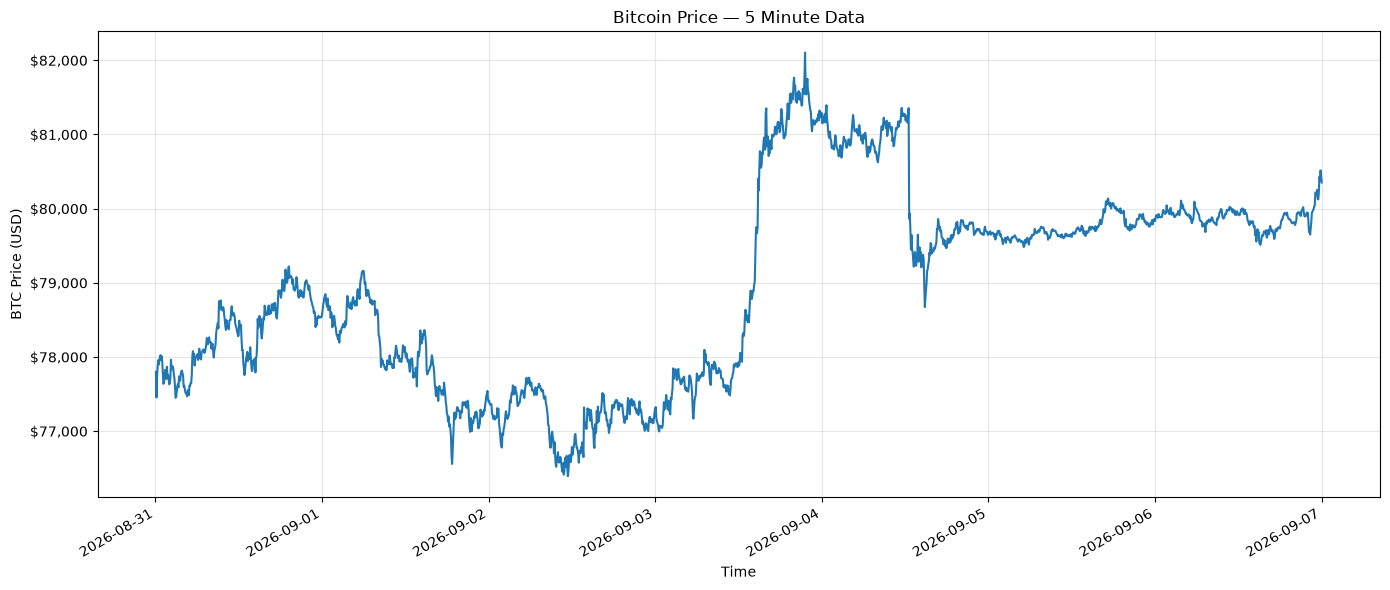

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    btc["timestamp"].to_list(),
    btc["price"].to_list(),
)

ax.set_title("Bitcoin Price — 5 Minute Data")
ax.set_xlabel("Time")
ax.set_ylabel("BTC Price (USD)")

ax.yaxis.set_major_formatter(
    StrMethodFormatter("${x:,.0f}")
)

ax.grid(alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [ ]:
url = "https://pro-api.coinmarketcap.com/v2/cryptocurrency/ohlcv/historical"

params = {
    "id": "1",
    "time_start": "2026-08-31",
    "time_end": "2026-09-07",
    "time_period": "hourly",
    "interval": "1h",
    "convert": "USD",
}

response = httpx.get(
    url,
    headers=headers,
    params=params,
)

response.raise_for_status()

data = response.json()

In [ ]:
quotes = data["data"]["quotes"]
quotes

[{'quote': {'USD': {'open': 77926.31044366962,
    'high': 77985.86369845341,
    'low': 77554.33932076214,
    'close': 77656.76455486756,
    'volume': 21043695485.94,
    'market_cap': 1559113034306.65,
    'timestamp': '2026-08-31T01:59:59.999Z'}},
  'time_open': '2026-08-31T01:00:00.000Z',
  'time_high': '2026-08-31T01:03:00.000Z',
  'time_low': '2026-08-31T01:14:00.000Z',
  'time_close': '2026-08-31T01:59:59.999Z'},
 {'quote': {'USD': {'open': 77654.66997995692,
    'high': 77985.38159273892,
    'low': 77378.43425294077,
    'close': 77451.82668693988,
    'volume': 21798807833.94,
    'market_cap': 1555267333175.44,
    'timestamp': '2026-08-31T02:59:59.999Z'}},
  'time_open': '2026-08-31T02:00:00.000Z',
  'time_high': '2026-08-31T02:15:00.000Z',
  'time_low': '2026-08-31T02:57:00.000Z',
  'time_close': '2026-08-31T02:59:59.999Z'},
 {'quote': {'USD': {'open': 77463.07716698028,
    'high': 77838.99862965287,
    'low': 77399.00760772225,
    'close': 77749.0567971226,
    'volu

In [ ]:
btc = pl.DataFrame({
    "timestamp": [q['time_open'] for q in quotes],
    "open": [q["quote"]["USD"]["open"] for q in quotes],
    "high": [q["quote"]["USD"]["high"] for q in quotes],
    "low": [q["quote"]["USD"]["low"] for q in quotes],
    "close": [q["quote"]["USD"]["close"] for q in quotes],
    "volume": [q["quote"]["USD"]["volume"] for q in quotes],
})

btc

timestamp,open,high,low,close,volume
str,f64,f64,f64,f64,f64
"""2026-08-31T01:00:00.000Z""",77926.310444,77985.863698,77554.339321,77656.764555,2.1044e10
"""2026-08-31T02:00:00.000Z""",77654.66998,77985.381593,77378.434253,77451.826687,2.1799e10
"""2026-08-31T03:00:00.000Z""",77463.077167,77838.99863,77399.007608,77749.056797,2.2053e10
"""2026-08-31T04:00:00.000Z""",77753.994766,77757.584792,77453.168109,77635.756769,2.1884e10
"""2026-08-31T05:00:00.000Z""",77635.837507,78131.062217,77504.960005,78004.122987,2.3277e10
…,…,…,…,…,…
"""2026-09-06T21:00:00.000Z""",79896.219983,80034.852708,79876.008589,79942.171777,1.8311e10
"""2026-09-06T22:00:00.000Z""",79943.985926,80090.210956,79642.791976,80045.452853,1.8680e10
"""2026-09-06T23:00:00.000Z""",80049.357349,80530.650162,80016.609751,80350.04312,1.9392e10


In [ ]:
btc = btc.with_columns(
    pl.col("timestamp")
    .str.to_datetime(time_zone="UTC")
    .alias("timestamp")
)

btc.head()

timestamp,open,high,low,close,volume
"datetime[μs, UTC]",f64,f64,f64,f64,f64
2026-08-31 01:00:00 UTC,77926.310444,77985.863698,77554.339321,77656.764555,2.1044e10
2026-08-31 02:00:00 UTC,77654.66998,77985.381593,77378.434253,77451.826687,2.1799e10
2026-08-31 03:00:00 UTC,77463.077167,77838.99863,77399.007608,77749.056797,2.2053e10
2026-08-31 04:00:00 UTC,77753.994766,77757.584792,77453.168109,77635.756769,2.1884e10
2026-08-31 05:00:00 UTC,77635.837507,78131.062217,77504.960005,78004.122987,2.3277e10


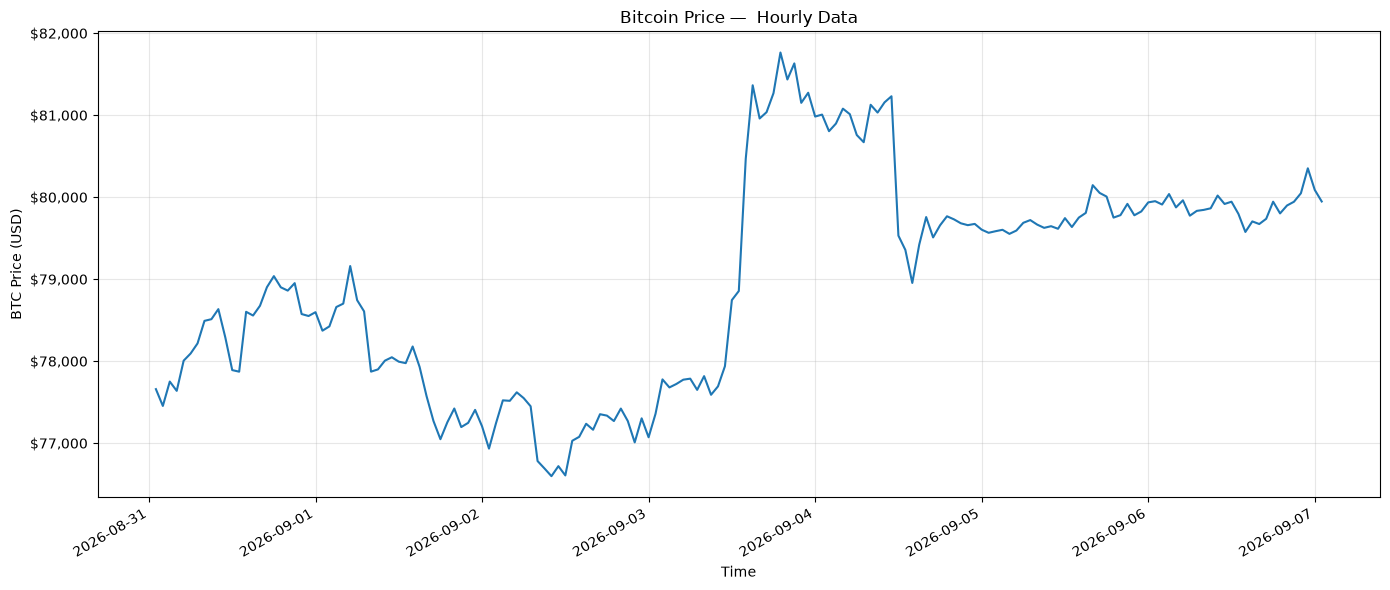

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    btc["timestamp"].to_list(),
    btc["close"].to_list(),
)

ax.set_title("Bitcoin Price —  Hourly Data")
ax.set_xlabel("Time")
ax.set_ylabel("BTC Price (USD)")

ax.yaxis.set_major_formatter(
    StrMethodFormatter("${x:,.0f}")
)

ax.grid(alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [29]:
import httpx
import os
from dotenv import load_dotenv
import polars as pl

load_dotenv()

API_KEY = os.getenv("CMC_API_KEY")

headers = {
    "X-CMC_PRO_API_KEY": API_KEY,
    "Accept": "application/json",
}

url = (
    "https://pro-api.coinmarketcap.com"
    "/v5/cryptocurrency/derivatives/market-pairs/list/latest"
)

params = {
    "crypto_id": 1,
    "category": "perpetual",
    "limit": 20,
    "convert": "USD",
}

response = httpx.get(
    url,
    headers=headers,
    params=params,
)

print(response.status_code)

data = response.json()
data

200


{'data': {'crypto_id': 1,
  'crypto_name': 'Bitcoin',
  'symbol': 'BTC',
  'num_market_pairs': 202,
  'market_pairs': [{'market_id': 979173,
    'market_pair_symbol': 'BTC/USDT',
    'category': 'perpetual',
    'fee_type': 'percentage',
    'outlier_detected': False,
    'exclusions': ['price', 'volume'],
    'exchange': {'exchange_id': 21,
     'exchange_name': 'BTCC',
     'exchange_slug': 'btcc'},
    'market_pair_base': {'crypto_id': 1,
     'symbol': 'BTC',
     'exchange_symbol': 'BTC',
     'currency_type': 'cryptocurrency'},
    'market_pair_quote': {'crypto_id': 825,
     'symbol': 'USDT',
     'exchange_symbol': 'USDT',
     'currency_type': 'cryptocurrency'},
    'exchange_reported_quotes': [{'convert_id': 2781,
      'convert_symbol': 'USD',
      'price': 79077.43,
      'volume_24h_base': 183423.0704137,
      'volume_24h_quote': 14504625011.02468,
      'open_interest': 8456751841.147491,
      'index_price': 79068.79793261,
      'index_basis': -2.215790603e-05,
      

In [30]:
type(data)

dict

In [31]:
list(data['data']['market_pairs'][0].keys())



['market_id',
 'market_pair_symbol',
 'category',
 'fee_type',
 'outlier_detected',
 'exclusions',
 'exchange',
 'market_pair_base',
 'market_pair_quote',
 'exchange_reported_quotes',
 'quotes']

In [32]:
data['data']['market_pairs'][0]['exchange_reported_quotes'][0]

{'convert_id': 2781,
 'convert_symbol': 'USD',
 'price': 79077.43,
 'volume_24h_base': 183423.0704137,
 'volume_24h_quote': 14504625011.02468,
 'open_interest': 8456751841.147491,
 'index_price': 79068.79793261,
 'index_basis': -2.215790603e-05,
 'funding_rate': -0.000143,
 'last_updated': '2026-09-09T10:30:15.000Z'}

In [33]:
data['data']['market_pairs'][0]['quotes'][0]

{'convert_id': 2781,
 'convert_symbol': 'USD',
 'price': 79070.5499316,
 'volume_24h': 14503363047.75322,
 'open_interest': 8456751841.147491,
 'last_updated': '2026-09-09T10:30:15.000Z'}

In [34]:
market_pairs = data["data"]["market_pairs"]

rows = []

for market in market_pairs:

    reported = market["exchange_reported_quotes"][0]

    rows.append({
        "timestamp": reported["last_updated"],
        "crypto_id": data["data"]["crypto_id"],
        "asset": data["data"]["crypto_name"],
        "symbol": data["data"]["symbol"],

        "market_id": market["market_id"],
        "market_pair": market["market_pair_symbol"],
        "category": market["category"],

        "exchange_id": market["exchange"]["exchange_id"],
        "exchange": market["exchange"]["exchange_name"],

        "quote_symbol": market["market_pair_quote"]["symbol"],

        "price": reported["price"],
        "volume_24h_base": reported["volume_24h_base"],
        "volume_24h_quote": reported["volume_24h_quote"],
        "open_interest": reported["open_interest"],
        "index_price": reported["index_price"],
        "index_basis": reported["index_basis"],
        "funding_rate": reported["funding_rate"],

        "outlier_detected": market["outlier_detected"],
        "exclusions": market["exclusions"],
    })

df = pl.DataFrame(rows)

In [35]:
df.head()

timestamp,crypto_id,asset,symbol,market_id,market_pair,category,exchange_id,exchange,quote_symbol,price,volume_24h_base,volume_24h_quote,open_interest,index_price,index_basis,funding_rate,outlier_detected,exclusions
str,i64,str,str,i64,str,str,i64,str,str,f64,f64,f64,f64,f64,f64,f64,bool,list[str]
"""2026-09-09T10:30:15.000Z""",1,"""Bitcoin""","""BTC""",979173,"""BTC/USDT""","""perpetual""",21,"""BTCC""","""USDT""",79077.43,183423.070414,1.4505e10,8.4568e9,79068.797933,-0.000022,-0.000143,false,"[""price"", ""volume""]"
"""2026-09-09T10:30:16.000Z""",1,"""Bitcoin""","""BTC""",1308539,"""BTC/USDT""","""perpetual""",9449,"""Echobit""","""USDT""",79040.2,149076.6526,1.1783e10,1.3634e9,79030.969562,0.000077,1.6055e-8,false,"[""volume""]"
"""2026-09-09T10:30:17.000Z""",1,"""Bitcoin""","""BTC""",47150,"""BTC/USDT""","""perpetual""",270,"""Binance""","""USDT""",79030.9,126659.437775,1.0010e10,8.3408e9,79032.164417,0.00021,0.000063,false,[]
"""2026-09-09T10:30:15.000Z""",1,"""Bitcoin""","""BTC""",975959,"""BTC/USDT""","""perpetual""",1645,"""Tapbit""","""USDT""",79045.5,115036.88,9.0931e9,3.8549e9,79038.571233,0.000106,0.000063,false,"[""price""]"
"""2026-09-09T10:30:15.000Z""",1,"""Bitcoin""","""BTC""",83657,"""BTC/USDT""","""perpetual""",407,"""DigiFinex""","""USDT""",79042.2,105372.603,8.3289e9,3.0185e9,79070.367761,0.000443,-0.00002,false,"[""price""]"


In [40]:
pl.Config.set_tbl_rows(-1)
pl.Config.set_tbl_cols(-1)

polars.config.Config

In [41]:
print(df.select([
    "exchange",
    "open_interest",
    "funding_rate",
    "index_basis",
    "outlier_detected",
]))

shape: (20, 5)
┌─────────────────────────────────┬───────────────┬──────────────┬─────────────┬──────────────────┐
│ exchange                        ┆ open_interest ┆ funding_rate ┆ index_basis ┆ outlier_detected │
│ ---                             ┆ ---           ┆ ---          ┆ ---         ┆ ---              │
│ str                             ┆ f64           ┆ f64          ┆ f64         ┆ bool             │
╞═════════════════════════════════╪═══════════════╪══════════════╪═════════════╪══════════════════╡
│ BTCC                            ┆ 8.4568e9      ┆ -0.000143    ┆ -0.000022   ┆ false            │
│ Echobit                         ┆ 1.3634e9      ┆ 1.6055e-8    ┆ 0.000077    ┆ false            │
│ Binance                         ┆ 8.3408e9      ┆ 0.000063     ┆ 0.00021     ┆ false            │
│ Tapbit                          ┆ 3.8549e9      ┆ 0.000063     ┆ 0.000106    ┆ false            │
│ DigiFinex                       ┆ 3.0185e9      ┆ -0.00002     ┆ 0.000443    ┆ fals

In [42]:
print(df.select([
    "exchange",
    "market_pair",
    "quote_symbol",
    "open_interest",
    "funding_rate",
    "index_basis",
    "outlier_detected",
    "exclusions",
]).sort(
    "open_interest",
    descending=True
))

shape: (20, 8)
┌────────────┬────────────┬────────────┬───────────┬───────────┬───────────┬───────────┬───────────┐
│ exchange   ┆ market_pai ┆ quote_symb ┆ open_inte ┆ funding_r ┆ index_bas ┆ outlier_d ┆ exclusion │
│ ---        ┆ r          ┆ ol         ┆ rest      ┆ ate       ┆ is        ┆ etected   ┆ s         │
│ str        ┆ ---        ┆ ---        ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
│            ┆ str        ┆ str        ┆ f64       ┆ f64       ┆ f64       ┆ bool      ┆ list[str] │
╞════════════╪════════════╪════════════╪═══════════╪═══════════╪═══════════╪═══════════╪═══════════╡
│ BTCC       ┆ BTC/USDT   ┆ USDT       ┆ 8.4568e9  ┆ -0.000143 ┆ -0.000022 ┆ false     ┆ ["price", │
│            ┆            ┆            ┆           ┆           ┆           ┆           ┆ "volume"] │
│ Binance    ┆ BTC/USDT   ┆ USDT       ┆ 8.3408e9  ┆ 0.000063  ┆ 0.00021   ┆ false     ┆ []        │
│ BitMart    ┆ BTC/USDT   ┆ USDT       ┆ 6.0782e9  ┆ 0.0000909 ┆ 0.000474  ┆

In [43]:
url = (
    "https://pro-api.coinmarketcap.com"
    "/v5/derivatives/liquidations/cryptocurrency/list/latest"
)

params = {
    "crypto_id": "1,1027,5426",
    "convert": "USD",
}

response = httpx.get(
    url,
    headers=headers,
    params=params,
)

print(response.status_code)

liquidation_data = response.json()

liquidation_data

200


{'data': {'cryptocurrencies': [{'name': 'Bitcoin',
    'symbol': 'BTC',
    'slug': 'bitcoin',
    'quotes': [{'symbol': 'USD',
      'crypto_id': 2781,
      'total_liquidations_1h': 942361.56449125,
      'long_liquidations_1h': 34135.06585,
      'short_liquidations_1h': 908226.49864125,
      'total_liquidations_4h': 4927935.82114425,
      'long_liquidations_4h': 2670469.929394,
      'short_liquidations_4h': 2257465.89175025,
      'total_liquidations_24h': 61934383.59883322,
      'long_liquidations_24h': 34237441.99802112,
      'short_liquidations_24h': 27696941.6008121,
      'last_updated': '2026-09-09T12:35:00.000Z'}],
    'crypto_id': 1,
    'cmc_rank': 1},
   {'name': 'Ethereum',
    'symbol': 'ETH',
    'slug': 'ethereum',
    'quotes': [{'symbol': 'USD',
      'crypto_id': 2781,
      'total_liquidations_1h': 265484.34604,
      'long_liquidations_1h': 11732.4117,
      'short_liquidations_1h': 253751.93434,
      'total_liquidations_4h': 3085599.46781,
      'long_liqu

In [51]:
liquidation_data["data"].keys()

dict_keys(['cryptocurrencies', 'total_size', 'has_more'])

In [52]:
liquidation_data["data"]['cryptocurrencies'][0].keys()

dict_keys(['name', 'symbol', 'slug', 'quotes', 'crypto_id', 'cmc_rank'])

In [49]:
list(liquidation_data["data"]['cryptocurrencies'][0]['quotes'][0].keys())

['symbol',
 'crypto_id',
 'total_liquidations_1h',
 'long_liquidations_1h',
 'short_liquidations_1h',
 'total_liquidations_4h',
 'long_liquidations_4h',
 'short_liquidations_4h',
 'total_liquidations_24h',
 'long_liquidations_24h',
 'short_liquidations_24h',
 'last_updated']

In [53]:
btc = liquidation_data["data"]["cryptocurrencies"][0]
q = btc["quotes"][0]

imbalance_1h = (
    q["long_liquidations_1h"]
    - q["short_liquidations_1h"]
) / q["total_liquidations_1h"]

imbalance_1h

-0.9275542060792167

In [54]:
cryptocurrencies = liquidation_data["data"]["cryptocurrencies"]

rows = []

for crypto in cryptocurrencies:

    quote = crypto["quotes"][0]

    rows.append({
        "timestamp": quote["last_updated"],
        "crypto_id": crypto["crypto_id"],
        "asset": crypto["name"],
        "symbol": crypto["symbol"],

        "total_liquidations_1h": quote["total_liquidations_1h"],
        "long_liquidations_1h": quote["long_liquidations_1h"],
        "short_liquidations_1h": quote["short_liquidations_1h"],

        "total_liquidations_4h": quote["total_liquidations_4h"],
        "long_liquidations_4h": quote["long_liquidations_4h"],
        "short_liquidations_4h": quote["short_liquidations_4h"],

        "total_liquidations_24h": quote["total_liquidations_24h"],
        "long_liquidations_24h": quote["long_liquidations_24h"],
        "short_liquidations_24h": quote["short_liquidations_24h"],
    })

liq_df = pl.DataFrame(rows)

liq_df = liq_df.with_columns(
    pl.col("timestamp")
    .str.to_datetime(time_zone="UTC")
)

liq_df

timestamp,crypto_id,asset,symbol,total_liquidations_1h,long_liquidations_1h,short_liquidations_1h,total_liquidations_4h,long_liquidations_4h,short_liquidations_4h,total_liquidations_24h,long_liquidations_24h,short_liquidations_24h
"datetime[μs, UTC]",i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64
2026-09-09 12:35:00 UTC,1,"""Bitcoin""","""BTC""",942361.564491,34135.06585,908226.498641,4.9279e6,2.6705e6,2.2575e6,6.1934e7,3.4237e7,2.7697e7
2026-09-09 12:35:00 UTC,1027,"""Ethereum""","""ETH""",265484.34604,11732.4117,253751.93434,3.0856e6,2.4103e6,675313.38695,4.0031e7,2.0542e7,1.9489e7
2026-09-09 12:35:00 UTC,5426,"""Solana""","""SOL""",84453.2496,4719.7395,79733.5101,666135.1641,569441.105,96694.0591,6.6745e6,3.9475e6,2.7270e6


In [55]:
liq_df = liq_df.with_columns(

    (
        (
            pl.col("long_liquidations_1h")
            - pl.col("short_liquidations_1h")
        )
        / pl.col("total_liquidations_1h")
    ).alias("liquidation_imbalance_1h"),

    (
        pl.col("long_liquidations_1h")
        / pl.col("total_liquidations_1h")
    ).alias("long_liquidation_share_1h"),

    (
        pl.col("total_liquidations_1h")
        / (pl.col("total_liquidations_24h") / 24)
    ).alias("liquidation_acceleration_1h_vs_24h"),
)

In [56]:
liq_df

timestamp,crypto_id,asset,symbol,total_liquidations_1h,long_liquidations_1h,short_liquidations_1h,total_liquidations_4h,long_liquidations_4h,short_liquidations_4h,total_liquidations_24h,long_liquidations_24h,short_liquidations_24h,liquidation_imbalance_1h,long_liquidation_share_1h,liquidation_acceleration_1h_vs_24h
"datetime[μs, UTC]",i64,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2026-09-09 12:35:00 UTC,1,"""Bitcoin""","""BTC""",942361.564491,34135.06585,908226.498641,4.9279e6,2.6705e6,2.2575e6,6.1934e7,3.4237e7,2.7697e7,-0.927554,0.036223,0.365172
2026-09-09 12:35:00 UTC,1027,"""Ethereum""","""ETH""",265484.34604,11732.4117,253751.93434,3.0856e6,2.4103e6,675313.38695,4.0031e7,2.0542e7,1.9489e7,-0.911615,0.044192,0.159166
2026-09-09 12:35:00 UTC,5426,"""Solana""","""SOL""",84453.2496,4719.7395,79733.5101,666135.1641,569441.105,96694.0591,6.6745e6,3.9475e6,2.7270e6,-0.888228,0.055886,0.303676


In [57]:
liq_df = liq_df.with_columns(

    (
        pl.col("total_liquidations_1h")
        /
        (
            (
                pl.col("total_liquidations_4h")
                - pl.col("total_liquidations_1h")
            ) / 3
        )
    ).alias("liquidation_intensity_1h_vs_prev3h"),

    (
        pl.col("total_liquidations_1h")
        /
        (pl.col("total_liquidations_24h") / 24)
    ).alias("liquidation_intensity_1h_vs_24h"),

)

In [58]:
liq_df = liq_df.with_columns(

    (
        (
            pl.col("long_liquidations_1h")
            - pl.col("short_liquidations_1h")
        )
        / pl.col("total_liquidations_1h")
    ).alias("liquidation_imbalance_1h"),

    (
        (
            pl.col("long_liquidations_4h")
            - pl.col("short_liquidations_4h")
        )
        / pl.col("total_liquidations_4h")
    ).alias("liquidation_imbalance_4h"),

    (
        (
            pl.col("long_liquidations_24h")
            - pl.col("short_liquidations_24h")
        )
        / pl.col("total_liquidations_24h")
    ).alias("liquidation_imbalance_24h"),

)

In [59]:
url = (
    "https://pro-api.coinmarketcap.com"
    "/v5/derivatives/liquidations/quotes/latest"
)

params = {
    "convert": "USD",
}

response = httpx.get(
    url,
    headers=headers,
    params=params,
)

print(response.status_code)

global_liquidation_data = response.json()

global_liquidation_data

200


{'data': {'quotes': [{'symbol': 'USD',
    'crypto_id': 2781,
    'total_liquidations_1h': 6458489.222467679,
    'long_liquidations_1h': 1314455.6910147048,
    'short_liquidations_1h': 5144033.531452973,
    'total_liquidations_4h': 28580797.249042634,
    'long_liquidations_4h': 15901911.074919999,
    'short_liquidations_4h': 12678886.174122633,
    'total_liquidations_24h': 214414579.08001664,
    'long_liquidations_24h': 111513394.43630368,
    'short_liquidations_24h': 102901184.64371297,
    'last_updated': '2026-09-09T12:51:00.000Z'}]},
 'status': {'timestamp': '2026-09-09T12:53:23.977Z',
  'error_code': '0',
  'error_message': '',
  'elapsed': 3,
  'credit_count': 1}}

In [60]:
url = (
    "https://pro-api.coinmarketcap.com"
    "/v5/derivatives/liquidations/exchange/list/latest"
)

params = {
    "start": 1,
    "limit": 50,
    "convert": "USD",
}

response = httpx.get(
    url,
    headers=headers,
    params=params,
)

print(response.status_code)

exchange_liquidation_data = response.json()

exchange_liquidation_data

200


{'data': {'exchanges': [{'name': 'Binance',
    'slug': 'binance',
    'quotes': [{'symbol': 'USD',
      'crypto_id': 2781,
      'total_liquidations_1h': 3660360.49666568,
      'long_liquidations_1h': 985425.71918765,
      'short_liquidations_1h': 2674934.77747803,
      'total_liquidations_4h': 14546045.31966991,
      'long_liquidations_4h': 8103863.27394497,
      'short_liquidations_4h': 6442182.04572494,
      'total_liquidations_24h': 102633237.32681417,
      'long_liquidations_24h': 53126561.93793762,
      'short_liquidations_24h': 49506675.38887656,
      'last_updated': '2026-09-09T12:53:00.000Z'}],
    'exchange_id': 270},
   {'name': 'Hyperliquid',
    'slug': 'hyperliquid',
    'quotes': [{'symbol': 'USD',
      'crypto_id': 2781,
      'total_liquidations_1h': 631890.142361,
      'long_liquidations_1h': 166515.45243,
      'short_liquidations_1h': 465374.689931,
      'total_liquidations_4h': 2866922.903557,
      'long_liquidations_4h': 1176563.28208,
      'short_

In [70]:
exchange_liquidation_data['data']['exchanges'][0].keys()

dict_keys(['name', 'slug', 'quotes', 'exchange_id'])

In [71]:
exchange_liquidation_data['data']['exchanges'][0]['quotes']

[{'symbol': 'USD',
  'crypto_id': 2781,
  'total_liquidations_1h': 3660360.49666568,
  'long_liquidations_1h': 985425.71918765,
  'short_liquidations_1h': 2674934.77747803,
  'total_liquidations_4h': 14546045.31966991,
  'long_liquidations_4h': 8103863.27394497,
  'short_liquidations_4h': 6442182.04572494,
  'total_liquidations_24h': 102633237.32681417,
  'long_liquidations_24h': 53126561.93793762,
  'short_liquidations_24h': 49506675.38887656,
  'last_updated': '2026-09-09T12:53:00.000Z'}]

In [72]:
quote = global_liquidation_data["data"]["quotes"][0]

global_liq_df = pl.DataFrame({
    "timestamp": [quote["last_updated"]],

    "total_liquidations_1h": [quote["total_liquidations_1h"]],
    "long_liquidations_1h": [quote["long_liquidations_1h"]],
    "short_liquidations_1h": [quote["short_liquidations_1h"]],

    "total_liquidations_4h": [quote["total_liquidations_4h"]],
    "long_liquidations_4h": [quote["long_liquidations_4h"]],
    "short_liquidations_4h": [quote["short_liquidations_4h"]],

    "total_liquidations_24h": [quote["total_liquidations_24h"]],
    "long_liquidations_24h": [quote["long_liquidations_24h"]],
    "short_liquidations_24h": [quote["short_liquidations_24h"]],
})

global_liq_df = global_liq_df.with_columns(
    pl.col("timestamp")
    .str.to_datetime(time_zone="UTC")
)

In [73]:
quote = global_liquidation_data["data"]["quotes"][0]

global_liq_df = pl.DataFrame({
    "timestamp": [quote["last_updated"]],

    "total_liquidations_1h": [quote["total_liquidations_1h"]],
    "long_liquidations_1h": [quote["long_liquidations_1h"]],
    "short_liquidations_1h": [quote["short_liquidations_1h"]],

    "total_liquidations_4h": [quote["total_liquidations_4h"]],
    "long_liquidations_4h": [quote["long_liquidations_4h"]],
    "short_liquidations_4h": [quote["short_liquidations_4h"]],

    "total_liquidations_24h": [quote["total_liquidations_24h"]],
    "long_liquidations_24h": [quote["long_liquidations_24h"]],
    "short_liquidations_24h": [quote["short_liquidations_24h"]],
})

global_liq_df = global_liq_df.with_columns(
    pl.col("timestamp")
    .str.to_datetime(time_zone="UTC")
)

In [74]:
exchanges = exchange_liquidation_data["data"]["exchanges"]

rows = []

for exchange in exchanges:

    quote = exchange["quotes"][0]

    rows.append({
        "timestamp": quote["last_updated"],

        "exchange_id": exchange["exchange_id"],
        "exchange": exchange["name"],
        "slug": exchange["slug"],

        "total_liquidations_1h": quote["total_liquidations_1h"],
        "long_liquidations_1h": quote["long_liquidations_1h"],
        "short_liquidations_1h": quote["short_liquidations_1h"],

        "total_liquidations_4h": quote["total_liquidations_4h"],
        "long_liquidations_4h": quote["long_liquidations_4h"],
        "short_liquidations_4h": quote["short_liquidations_4h"],

        "total_liquidations_24h": quote["total_liquidations_24h"],
        "long_liquidations_24h": quote["long_liquidations_24h"],
        "short_liquidations_24h": quote["short_liquidations_24h"],
    })

exchange_liq_df = pl.DataFrame(rows)

exchange_liq_df = exchange_liq_df.with_columns(
    pl.col("timestamp")
    .str.to_datetime(time_zone="UTC")
)

In [75]:
exchange_liq_df = exchange_liq_df.with_columns(

    (
        (
            pl.col("long_liquidations_1h")
            - pl.col("short_liquidations_1h")
        )
        / pl.col("total_liquidations_1h")
    ).alias("liquidation_imbalance_1h"),

    (
        (
            pl.col("long_liquidations_4h")
            - pl.col("short_liquidations_4h")
        )
        / pl.col("total_liquidations_4h")
    ).alias("liquidation_imbalance_4h"),

    (
        (
            pl.col("long_liquidations_24h")
            - pl.col("short_liquidations_24h")
        )
        / pl.col("total_liquidations_24h")
    ).alias("liquidation_imbalance_24h"),

    (
        pl.col("total_liquidations_1h")
        / (pl.col("total_liquidations_24h") / 24)
    ).alias("liquidation_intensity_1h_vs_24h"),

    (
        pl.col("total_liquidations_1h")
        /
        (
            (
                pl.col("total_liquidations_4h")
                - pl.col("total_liquidations_1h")
            ) / 3
        )
    ).alias("liquidation_intensity_1h_vs_prev3h"),
)

In [76]:
exchange_liq_df = exchange_liq_df.with_columns(

    (
        pl.col("total_liquidations_1h")
        / pl.col("total_liquidations_1h").sum()
    ).alias("liquidation_share_1h"),

    (
        pl.col("total_liquidations_4h")
        / pl.col("total_liquidations_4h").sum()
    ).alias("liquidation_share_4h"),

    (
        pl.col("total_liquidations_24h")
        / pl.col("total_liquidations_24h").sum()
    ).alias("liquidation_share_24h"),
)

In [77]:
exchange_liq_df.select([
    "exchange",
    "total_liquidations_1h",
    "liquidation_share_1h",
    "liquidation_imbalance_1h",
    "liquidation_intensity_1h_vs_24h",
]).sort(
    "total_liquidations_1h",
    descending=True,
)

exchange,total_liquidations_1h,liquidation_share_1h,liquidation_imbalance_1h,liquidation_intensity_1h_vs_24h
str,f64,f64,f64,f64
"""Binance""",3.6604e6,0.596948,-0.461569,0.855947
"""Hyperliquid""",631890.142361,0.103051,-0.472961,0.439943
"""OKX""",595624.225471,0.097137,-0.70604,0.467028
"""Bybit""",545638.914606,0.088985,-0.76407,0.574741
"""Gate""",533831.2099,0.08706,-0.856007,0.81295
"""Aster""",81087.50681,0.013224,-0.978879,0.849974
"""Kraken""",42473.42967,0.006927,-1.0,0.662117
"""Bitfinex""",30320.475451,0.004945,-1.0,15.037999
"""HTX""",10565.2835,0.001723,0.994236,0.059455


In [78]:
exchange_total_1h = exchange_liq_df["total_liquidations_1h"].sum()

global_total_1h = global_liq_df["total_liquidations_1h"][0]

print("Global 1h:", global_total_1h)
print("Exchange sum 1h:", exchange_total_1h)
print("Difference:", global_total_1h - exchange_total_1h)

Global 1h: 6458489.222467679
Exchange sum 1h: 6131791.684433929
Difference: 326697.5380337499


In [79]:
for horizon in ["1h", "4h", "24h"]:

    exchange_total = exchange_liq_df[
        f"total_liquidations_{horizon}"
    ].sum()

    global_total = global_liq_df[
        f"total_liquidations_{horizon}"
    ][0]

    print(
        horizon,
        "global:",
        global_total,
        "exchange sum:",
        exchange_total,
        "difference:",
        global_total - exchange_total,
    )

1h global: 6458489.222467679 exchange sum: 6131791.684433929 difference: 326697.5380337499
4h global: 28580797.249042634 exchange sum: 28633712.10894062 difference: -52914.859897986054
24h global: 214414579.08001664 exchange sum: 214399799.20153016 difference: 14779.87848648429


In [80]:
global_1h = global_liq_df["total_liquidations_1h"][0]

exchange_liq_df = exchange_liq_df.with_columns(
    (
        pl.col("total_liquidations_1h")
        / global_1h
    ).alias("global_liquidation_share_1h")
)

In [81]:
unattributed_1h = (
    global_liq_df["total_liquidations_1h"][0]
    - exchange_liq_df["total_liquidations_1h"].sum()
)